1. Time-domain signal x(t):


exp(-alpha*Abs(t))


2. Analytical Laplace Transform X(s):


Piecewise((-1/((-I*omega - sigma)*(-alpha/(-I*omega - sigma) + 1)) + 1/(alpha*(1 + (-I*omega - sigma)/alpha)), (Abs(arg(-I*omega - sigma)) <= pi/2) & (Abs(arg(-I*omega - sigma) + pi) <= pi/2)), (Integral(exp(-alpha*Abs(t))*exp(t*(-I*omega - sigma)), (t, -oo, oo)), True))

\n3. Region of Convergence (ROC) and Poles Plot (-alpha < Re(s) < alpha):


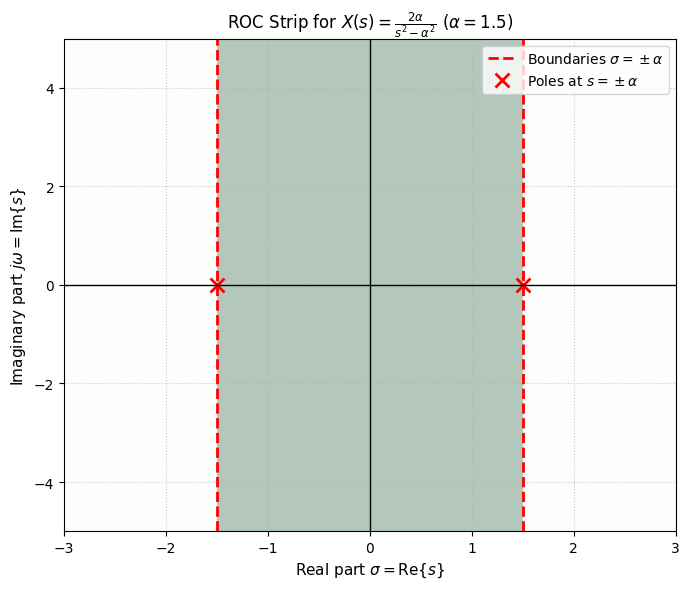

In [1]:
# Notebook: Analytical Laplace Transform, ROC, and Pole-Zero Plot for x(t) = e^{-\alpha |t|} (\alpha > 0)

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# 1. Define symbolic variables and parameters
t = sp.Symbol('t', real=True)
sigma, omega = sp.symbols('sigma omega', real=True)
alpha = sp.Symbol('alpha', positive=True, real=True)
s = sigma + sp.I * omega  # Complex variable s = \sigma + j\omega

# 2. Define signal x(t) = e^{-\alpha |t|}
x_t = sp.exp(-alpha * sp.Abs(t))

print("1. Time-domain signal x(t):")
display(x_t)

# 3. Compute bilateral Laplace Transform using integration definition over (-oo, oo)
# X(s) = \int_{-\infty}^{\infty} e^{-\alpha |t|} e^{-st} dt
X_s = sp.integrate(x_t * sp.exp(-s * t), (t, -sp.oo, sp.oo))

print("\n2. Analytical Laplace Transform X(s):")
display(X_s)

# 4. Visualizing the Strip Region of Convergence (ROC) and Poles for a specific alpha = 1.5
print(r"\n3. Region of Convergence (ROC) and Poles Plot (-alpha < Re(s) < alpha):")
fig, ax = plt.subplots(figsize=(7, 6))

sig_vals = np.linspace(-3, 3, 400)
om_vals = np.linspace(-5, 5, 400)
SIGMA, OMEGA = np.meshgrid(sig_vals, om_vals)

alpha_val = 1.5
# ROC condition for bilateral exponential: -\alpha < \sigma < \alpha
roc_mask = (SIGMA > -alpha_val) & (SIGMA < alpha_val)

ax.imshow(roc_mask, extent=(-3, 3, -5, 5), origin='lower', cmap='Greens', alpha=0.3, aspect='auto')

# Boundaries at \sigma = -\alpha and \sigma = \alpha
ax.axvline(x=-alpha_val, color='red', linestyle='--', linewidth=2, label=r'Boundaries $\sigma = \pm \alpha$')
ax.axvline(x=alpha_val, color='red', linestyle='--', linewidth=2)

# Poles at s = -\alpha and s = +\alpha
ax.plot(-alpha_val, 0.0, 'rx', markersize=10, markeredgewidth=2, label=r'Poles at $s = \pm \alpha$')
ax.plot(alpha_val, 0.0, 'rx', markersize=10, markeredgewidth=2)

ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlim(-3, 3)
ax.set_ylim(-5, 5)
ax.set_xlabel(r'Real part $\sigma = \text{Re}\{s\}$', fontsize=11)
ax.set_ylabel(r'Imaginary part $j\omega = \text{Im}\{s\}$', fontsize=11)
ax.set_title(r'ROC Strip for $X(s) = \frac{2\alpha}{s^2-\alpha^2}$ ($\alpha = 1.5$)', fontsize=12)
ax.grid(True, linestyle=':', alpha=0.7)
ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()